In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

# **EDA PART**

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=17PODOI-rj9G1jc99NhlhSPv2-5ABwbCF'
dataset = pd.read_csv(url)

In [ ]:
dataset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
dataset.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [ ]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(dataset.shape,dataset.shape[0],dataset.shape[1]))

Shape of the dataset is (5110, 12). This dataset contains 5110 rows and 12 columns.


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [ ]:
numerical_data = dataset.select_dtypes(include='number')

numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 7 numerical features: 

['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


In [ ]:
categorical_data=dataset.select_dtypes(include= 'object')

categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 5 categorical features: 

['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
gender,5110,3,Female,2994
ever_married,5110,2,Yes,3353
work_type,5110,5,Private,2925
Residence_type,5110,2,Urban,2596
smoking_status,5110,4,never smoked,1892


In [ ]:
numerical_data.var()

,0
id,4.478185e+08
age,5.113318e+02
hypertension,8.797552e-02
heart_disease,5.110447e-02
avg_glucose_level,2.050601e+03
bmi,6.168636e+01
stroke,4.636264e-02


In [ ]:
numerical_data.skew()

,0
id,-0.019913
age,-0.137059
hypertension,2.715392
heart_disease,3.947244
avg_glucose_level,1.572284
bmi,1.055340
stroke,4.193284


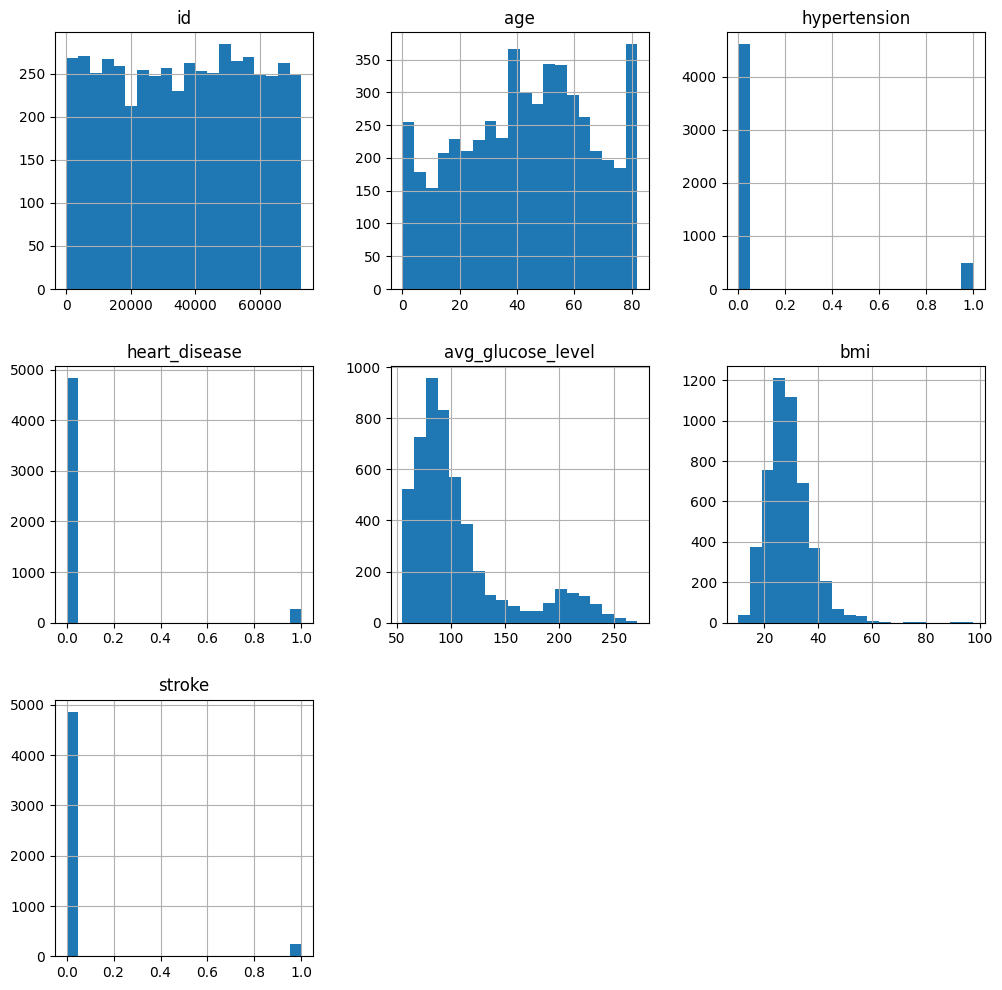

In [ ]:
numerical_data.hist(figsize=(12,12),bins=20)
plt.show()

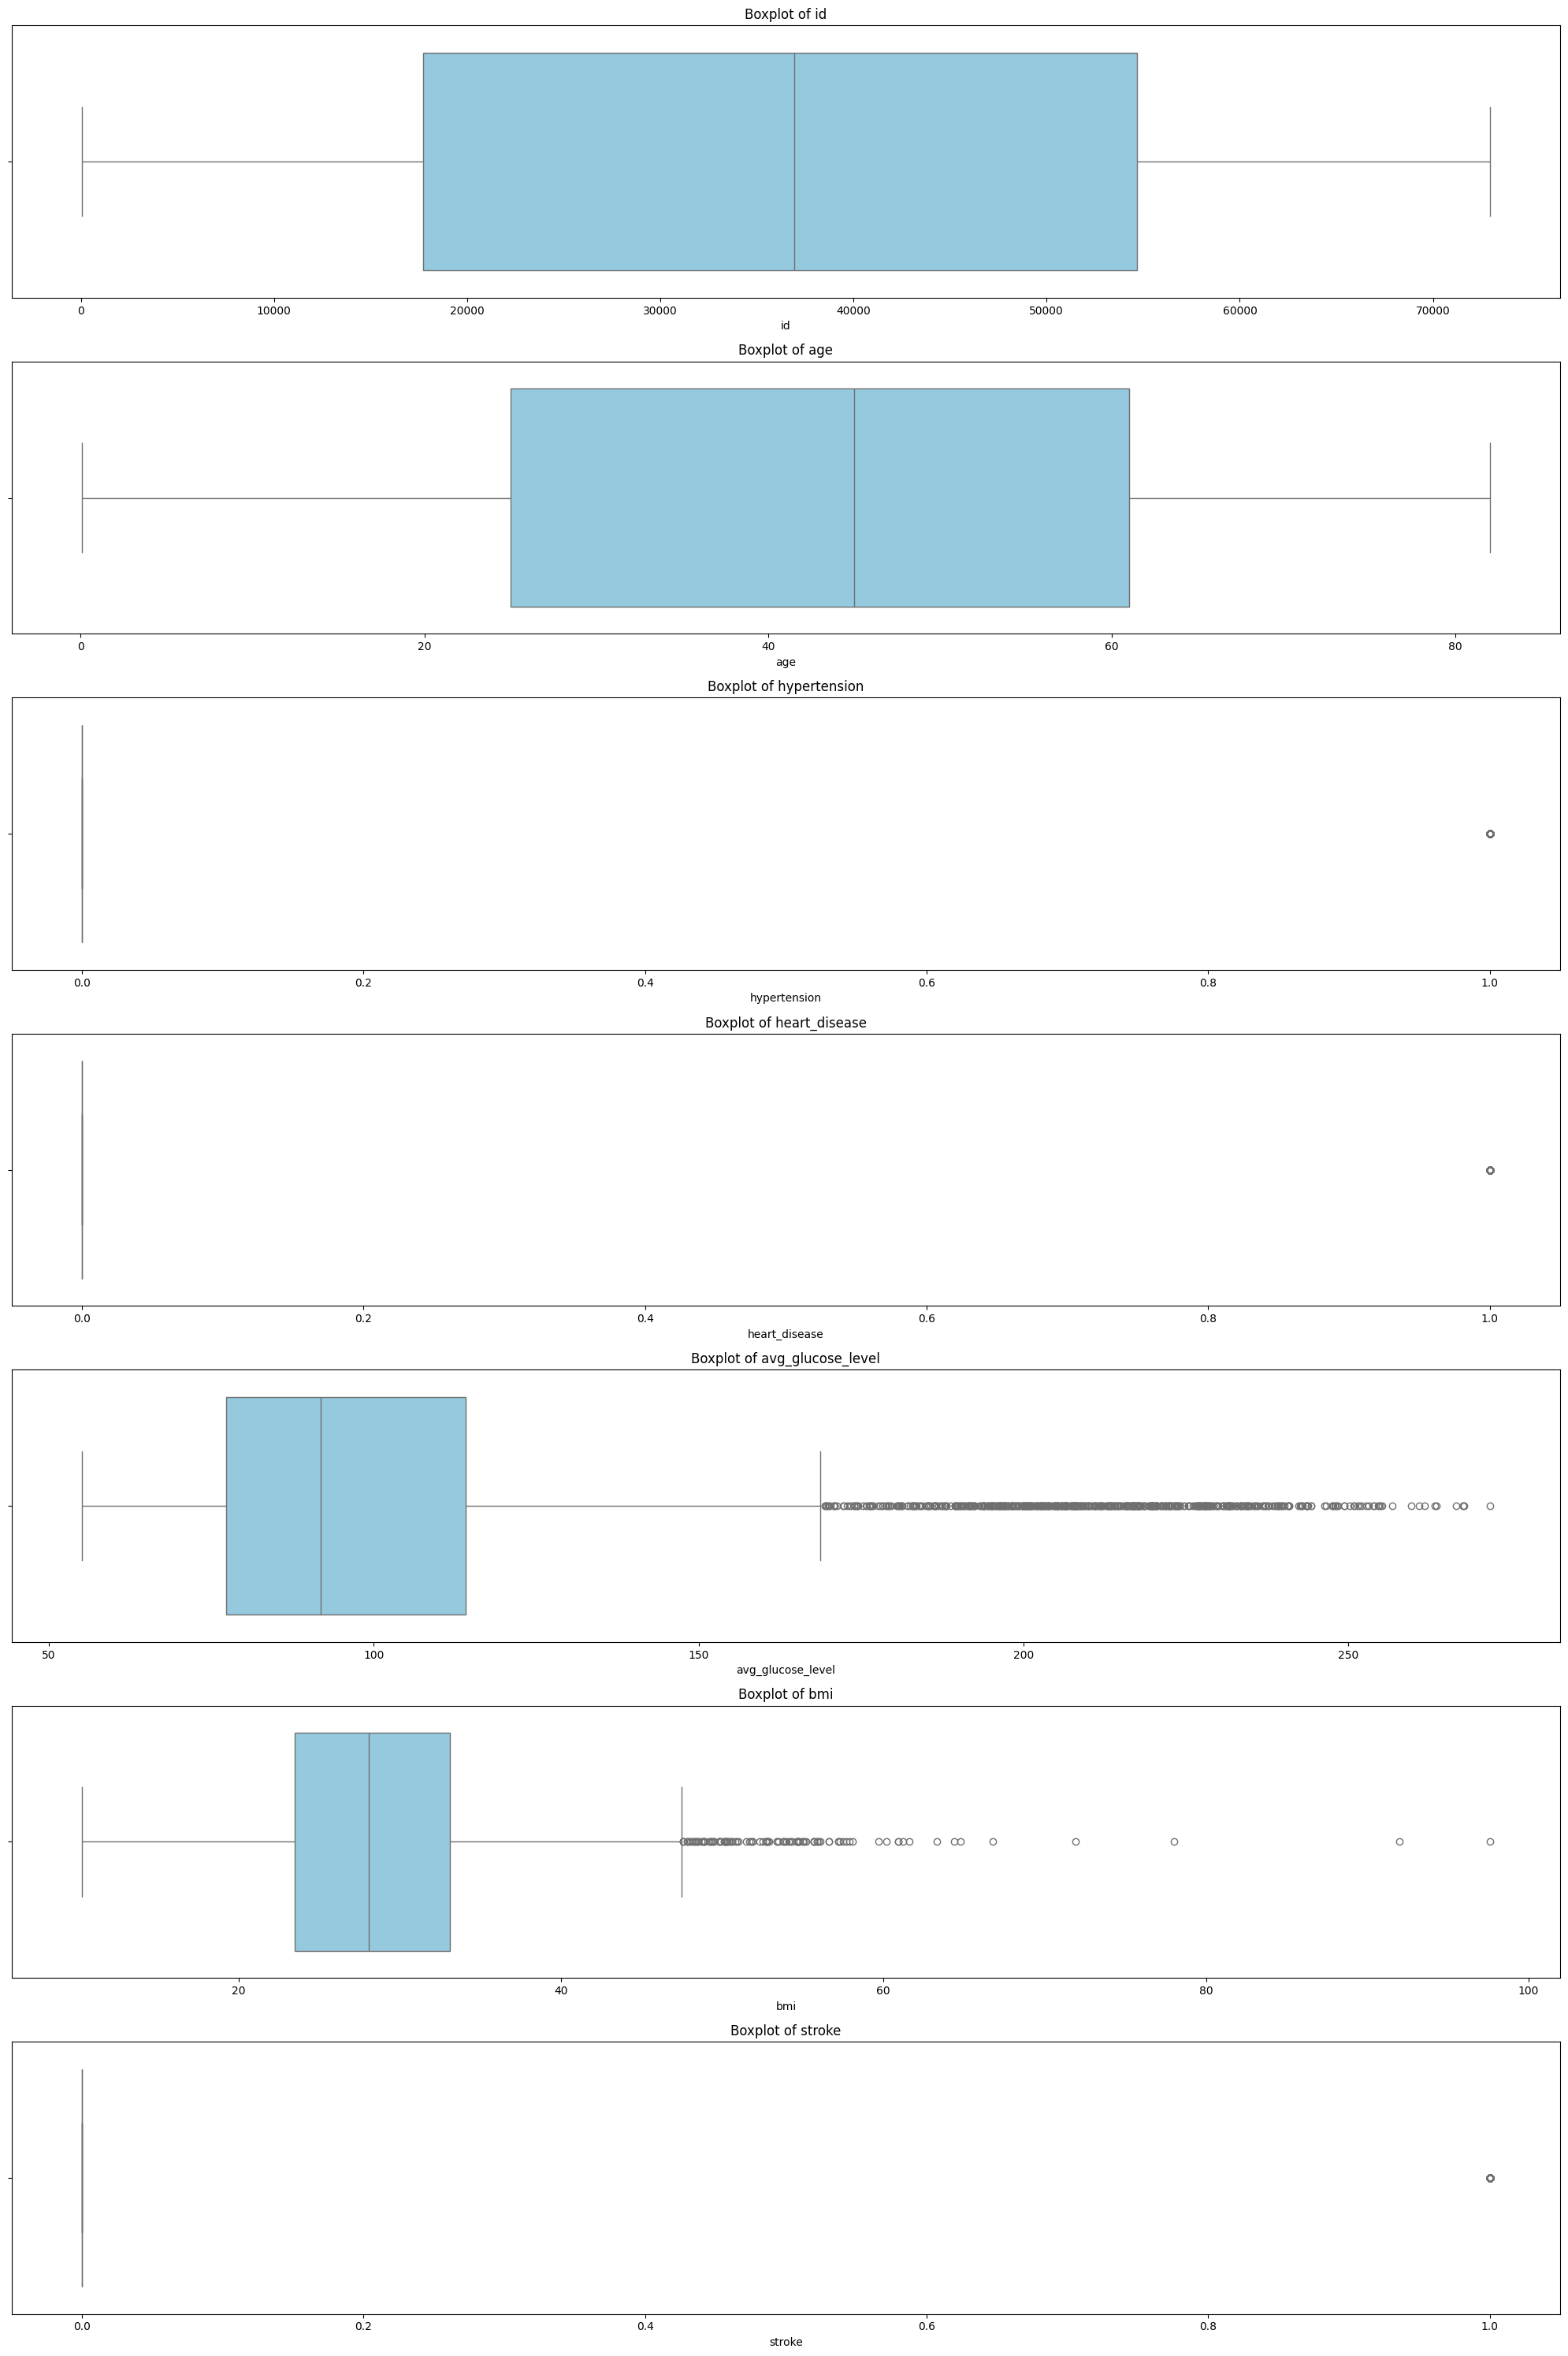

In [ ]:
numeric_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=dataset[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()


In [ ]:
numerical_data.nunique()

,0
id,5110
age,104
hypertension,2
heart_disease,2
avg_glucose_level,3979
bmi,418
stroke,2


In [ ]:
numerical_data.isnull().sum()

,0
id,0
age,0
hypertension,0
heart_disease,0
avg_glucose_level,0
bmi,201
stroke,0


In [ ]:
unique_counts=categorical_data.nunique()
print(unique_counts)

gender            3
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
dtype: int64


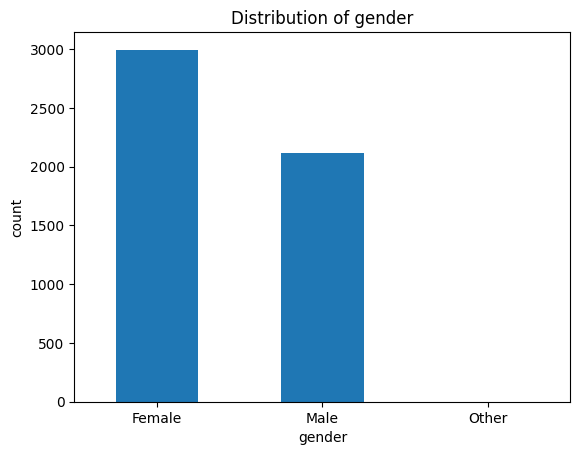

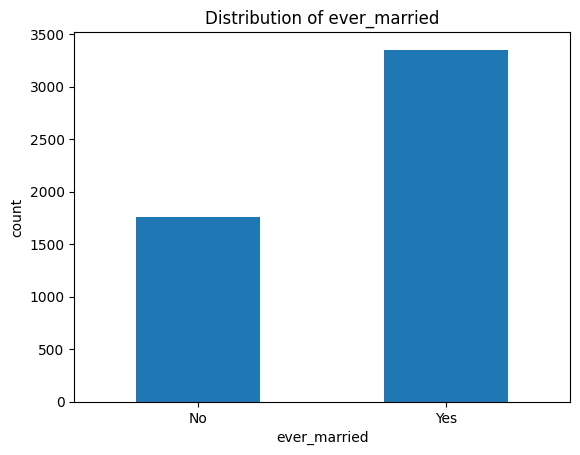

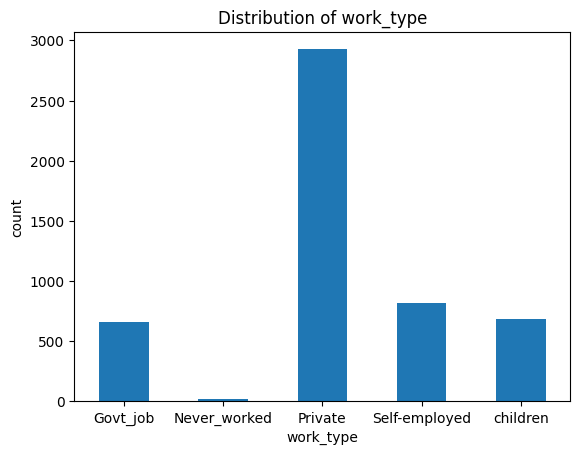

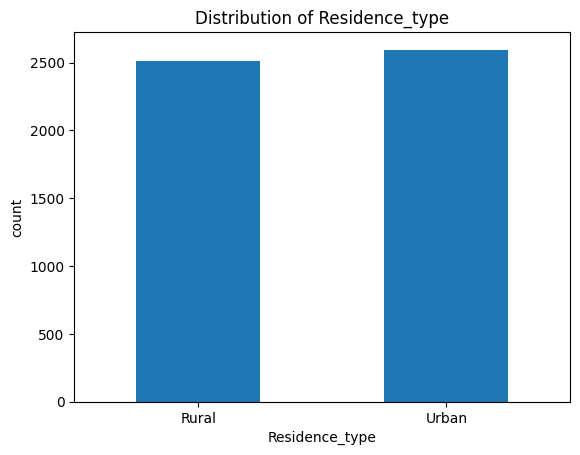

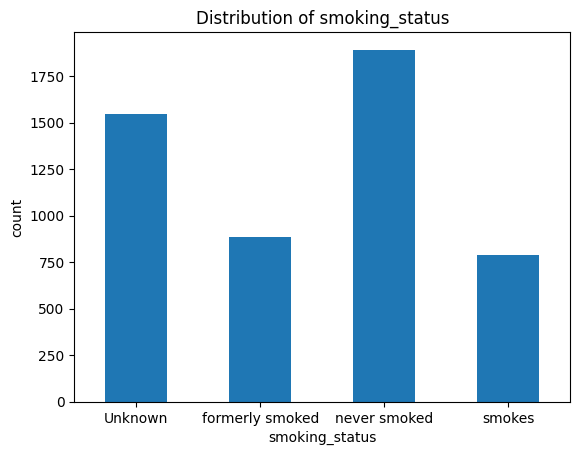

In [ ]:
for col in categorical_features:
    plt.title(f'Distribution of {col}')
    categorical_data[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

In [ ]:
correlation_matrix = numerical_data.corr()
correlation_matrix

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.000000,0.003538,0.003550,-0.001296,0.001092,0.003084,0.006388
age,0.003538,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257
hypertension,0.003550,0.276398,1.000000,0.108306,0.174474,0.167811,0.127904
heart_disease,-0.001296,0.263796,0.108306,1.000000,0.161857,0.041357,0.134914
avg_glucose_level,0.001092,0.238171,0.174474,0.161857,1.000000,0.175502,0.131945
bmi,0.003084,0.333398,0.167811,0.041357,0.175502,1.000000,0.042374
stroke,0.006388,0.245257,0.127904,0.134914,0.131945,0.042374,1.000000


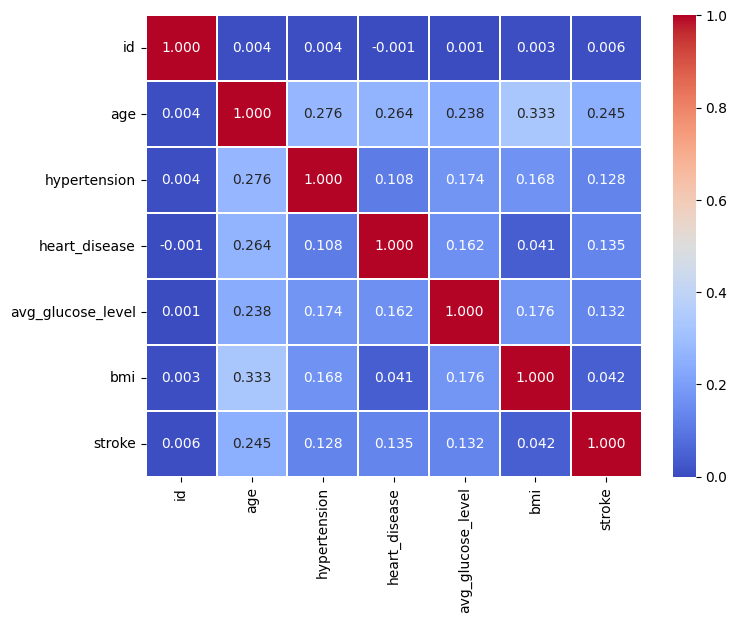

In [ ]:
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.3)
plt.show()

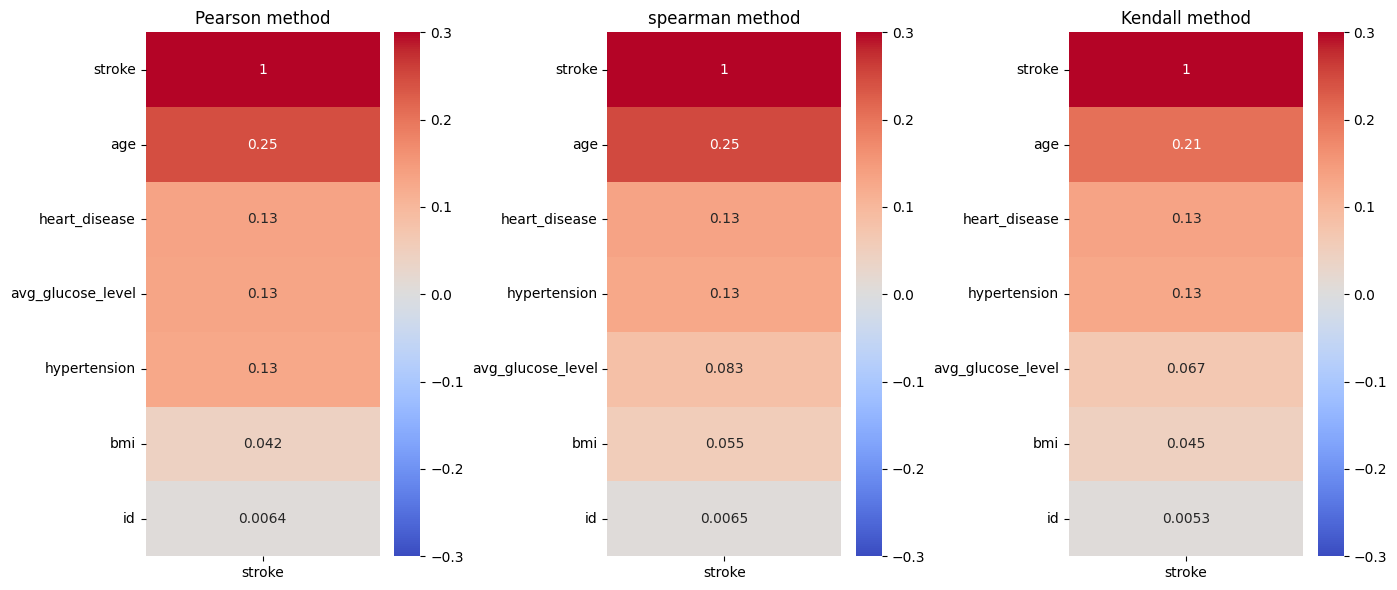

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

corr1 = numerical_data.corr('pearson')[['stroke']].sort_values(by='stroke', ascending=False)
corr2 = numerical_data.corr('spearman')[['stroke']].sort_values(by='stroke', ascending=False)
corr3 = numerical_data.corr('kendall')[['stroke']].sort_values(by='stroke', ascending=False)

ax[0].set_title('Pearson method')
ax[1].set_title('spearman method')
ax[2].set_title('Kendall method')

sns.heatmap(corr1, ax=ax[0], annot=True, cmap='coolwarm', vmin=-0.3, vmax=0.3)
sns.heatmap(corr2, ax=ax[1], annot=True, cmap='coolwarm', vmin=-0.3, vmax=0.3)
sns.heatmap(corr3, ax=ax[2], annot=True, cmap='coolwarm', vmin=-0.3, vmax=0.3)
plt.tight_layout()
plt.show()

In [ ]:
class_counts = dataset.groupby("stroke").size()

columns = ['stroke', 'count', 'percentage']
stroke = [0, 1]
count = list()
percentage = list()

total_rows = len(dataset)

for val in range(2):
    count.append(class_counts[val])
    percent = (class_counts[val] / total_rows) * 100
    percentage.append(percent)

imbalance_df = pd.DataFrame(list(zip(stroke, count, percentage)), columns=columns)
imbalance_df

,stroke,count,percentage
0,0,4861,95.127202
1,1,249,4.872798


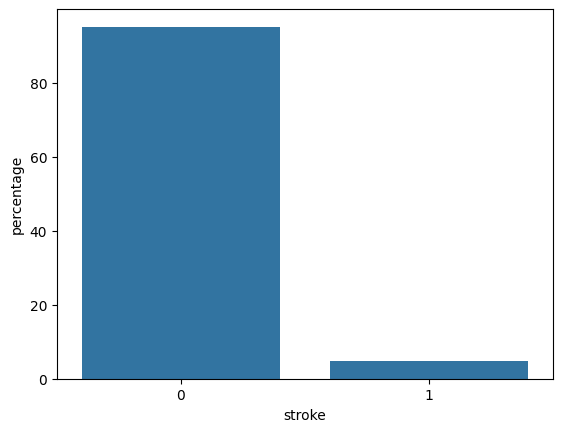

In [ ]:
sns.barplot(data=imbalance_df,x=imbalance_df['stroke'],y=imbalance_df['percentage'])
plt.show()

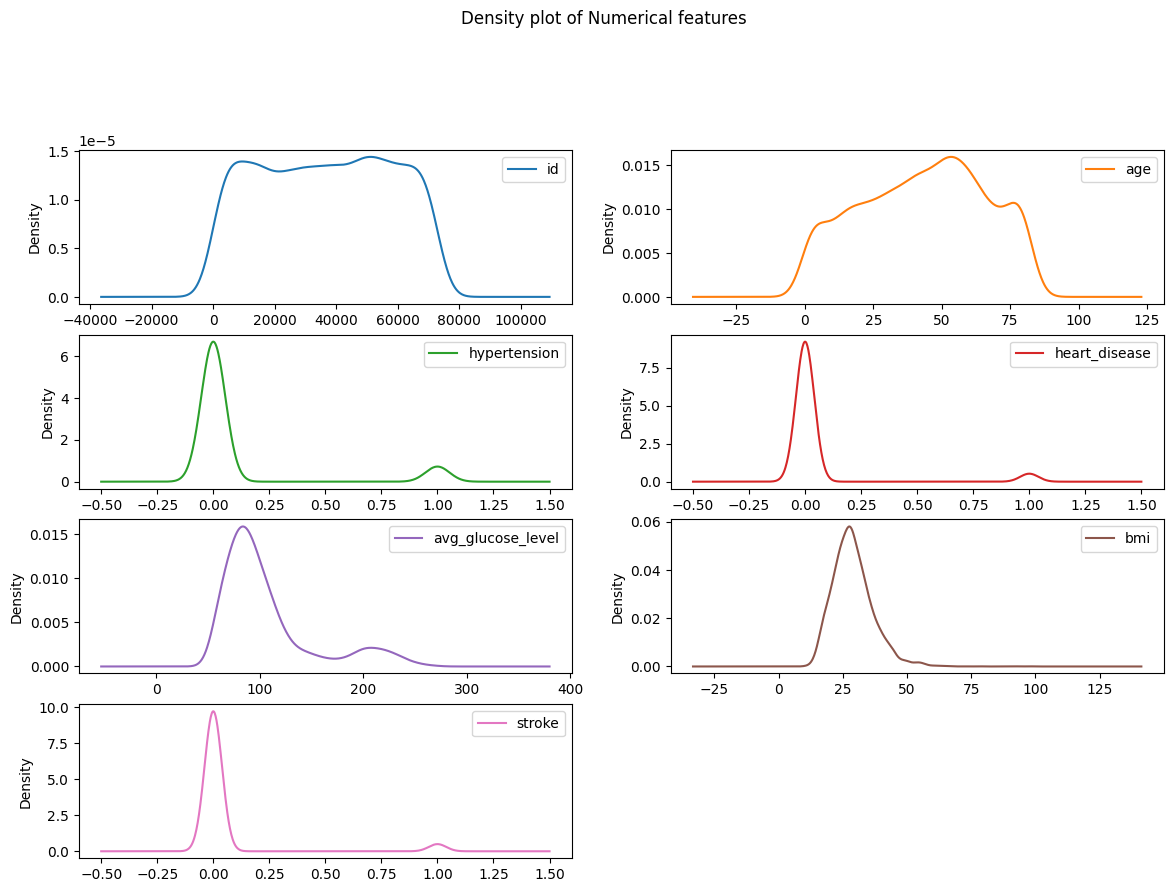

In [ ]:
numerical_data.plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

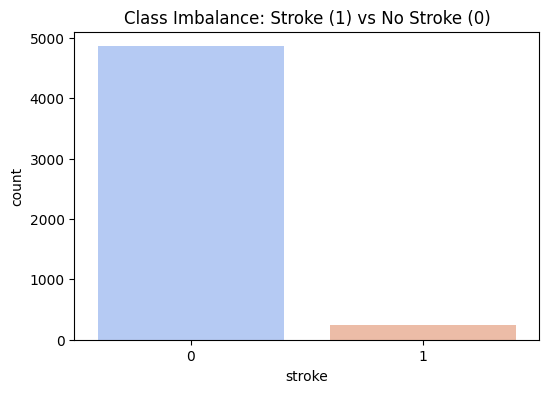

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(x='stroke', data=dataset, hue='stroke', legend=False, palette='coolwarm')

plt.title('Class Imbalance: Stroke (1) vs No Stroke (0)')
plt.show()

print(dataset['stroke'].value_counts(normalize=True) * 100)

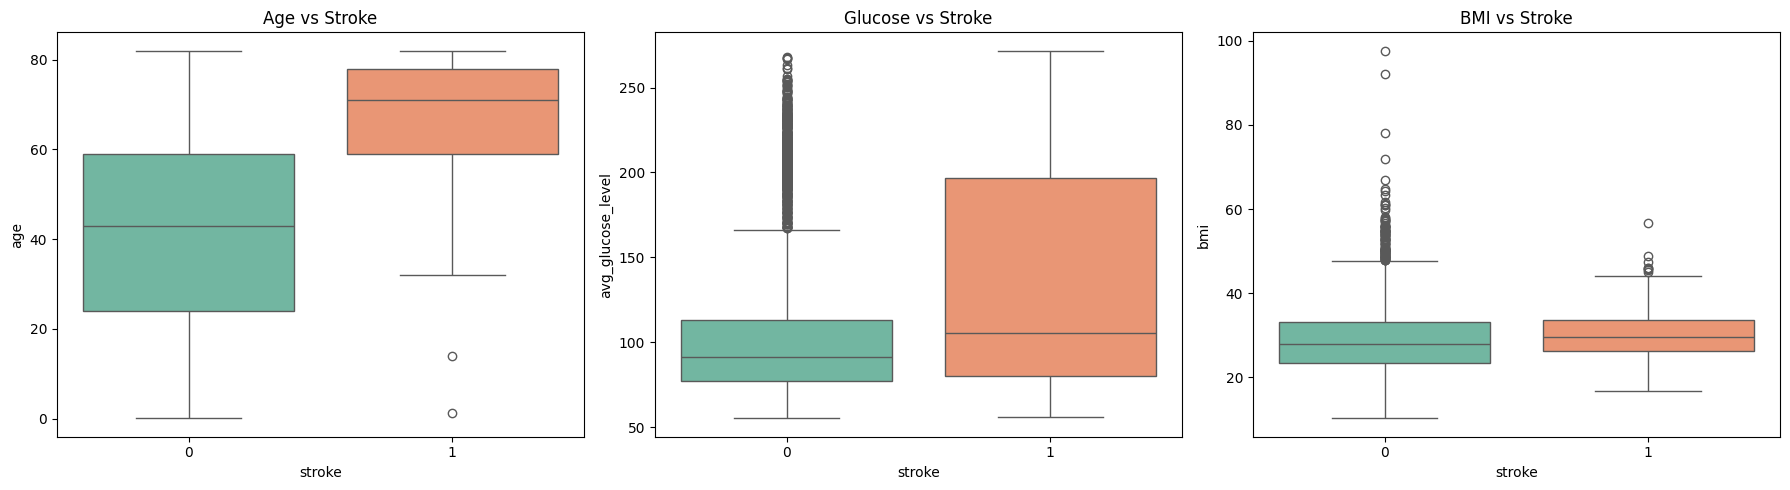

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='stroke', y='age', data=dataset, ax=axes[0], hue='stroke', legend=False, palette='Set2')
axes[0].set_title('Age vs Stroke')

sns.boxplot(x='stroke', y='avg_glucose_level', data=dataset, ax=axes[1], hue='stroke', legend=False, palette='Set2')
axes[1].set_title('Glucose vs Stroke')

sns.boxplot(x='stroke', y='bmi', data=dataset, ax=axes[2], hue='stroke', legend=False, palette='Set2')
axes[2].set_title('BMI vs Stroke')

plt.tight_layout()
plt.show()

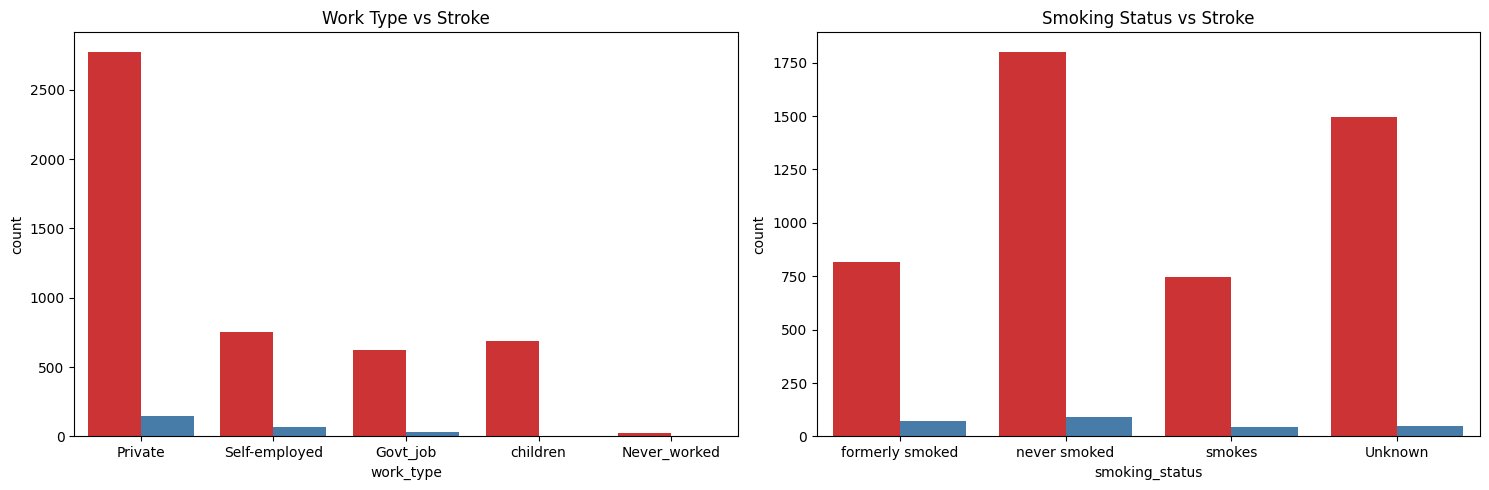

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(x='work_type', hue='stroke', data=dataset, ax=axes[0], legend=False, palette='Set1')
axes[0].set_title('Work Type vs Stroke')

sns.countplot(x='smoking_status', hue='stroke', data=dataset, ax=axes[1], legend=False, palette='Set1')
axes[1].set_title('Smoking Status vs Stroke')

plt.tight_layout()
plt.show()

# **Data Pre-processing**

In [ ]:
url = 'https://drive.google.com/uc?export=download&id=17PODOI-rj9G1jc99NhlhSPv2-5ABwbCF'
dataset = pd.read_csv(url)

In [ ]:
duplicates_count = dataset.duplicated().sum()
print(f"Duplicates found: {duplicates_count}")

if duplicates_count > 0:
    dataset.drop_duplicates(inplace=True)
    print("Duplicates removed!")

Duplicates found: 0


In [ ]:
dataset = dataset.drop(['id'], axis = 1)
dataset.shape

(5110, 11)

In [ ]:
dataset = dataset[dataset['gender'] != 'Other']
print("Unique genders left:", dataset['gender'].unique())

Unique genders left: ['Male' 'Female']


In [ ]:
dataset.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
impute = SimpleImputer(missing_values=np.nan, strategy='median')
impute.fit(dataset[['bmi']])
dataset['bmi'] = impute.transform(dataset[['bmi']])
print("Missing values in bmi:", dataset['bmi'].isnull().sum())

Missing values in bmi: 0


In [ ]:
dataset

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,28.1,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   float64
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 479.0+ KB


In [ ]:
dataset['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
dataset.shape

(5109, 11)

# **One-Hot Encoding (Feature Engineering)**

In [ ]:
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
dataset = pd.get_dummies(dataset, columns=categorical_cols, drop_first = True)

print("Columns after One-Hot Encoding:")
print(dataset.columns)
display(dataset.head())

Columns after One-Hot Encoding:
Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'stroke', 'gender_Male', 'ever_married_Yes', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,67.0,0,1,228.69,36.6,1,True,True,False,True,False,False,True,True,False,False
1,61.0,0,0,202.21,28.1,1,False,True,False,False,True,False,False,False,True,False
2,80.0,0,1,105.92,32.5,1,True,True,False,True,False,False,False,False,True,False
3,49.0,0,0,171.23,34.4,1,False,True,False,True,False,False,True,False,False,True
4,79.0,1,0,174.12,24.0,1,False,True,False,False,True,False,False,False,True,False


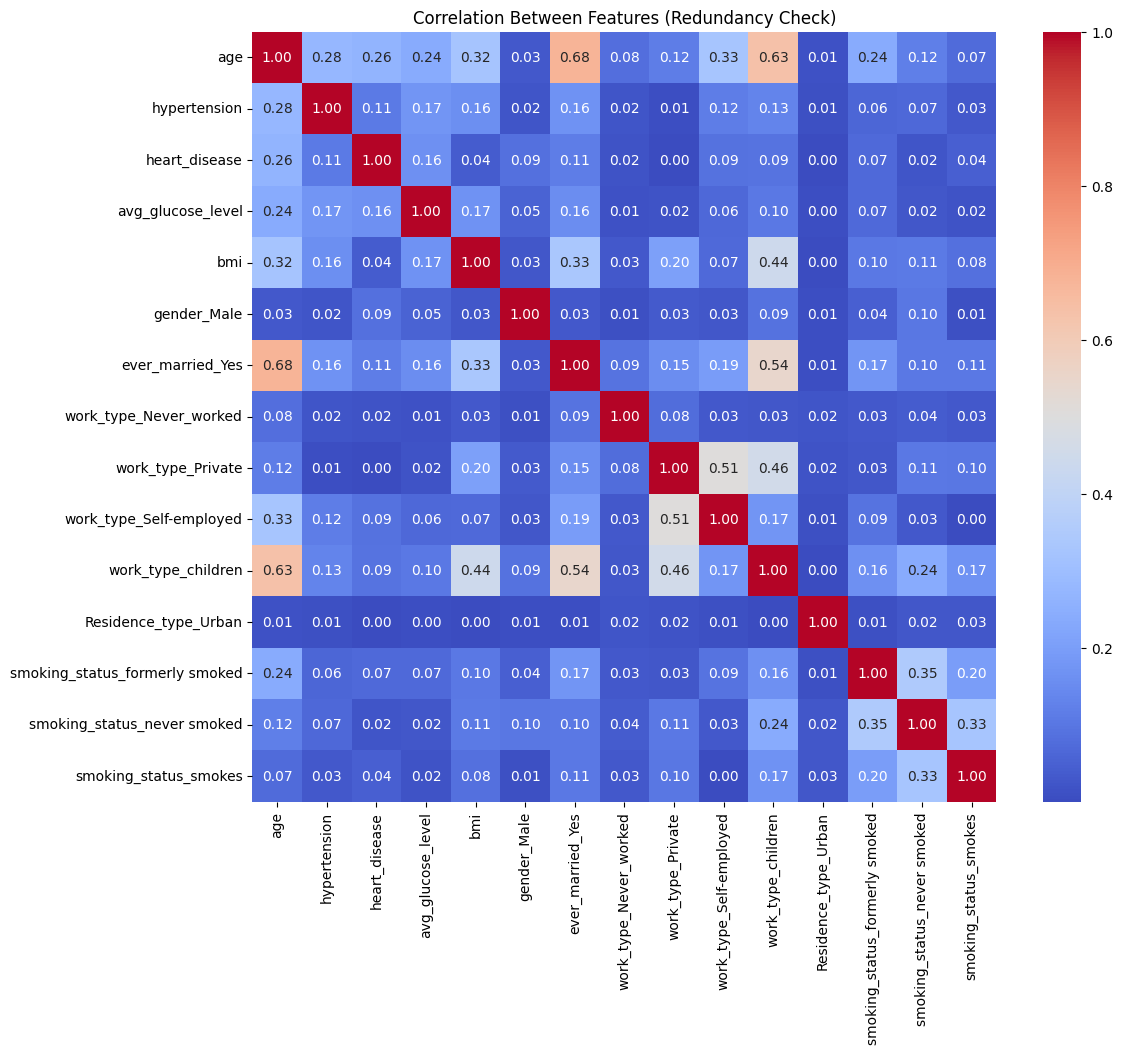

In [ ]:
features_only = dataset.drop('stroke', axis=1)

corr_matrix = features_only.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Features (Redundancy Check)')
plt.show()

In [ ]:
features_only.corr()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
age,1.000000,0.276367,0.263777,0.238323,0.324211,-0.027752,0.679084,-0.078667,0.116678,0.327949,-0.634320,0.014031,0.237347,0.119207,0.073075
hypertension,0.276367,1.000000,0.108292,0.174540,0.158252,0.021223,0.164187,-0.021612,-0.005358,0.115417,-0.129535,-0.007980,0.059022,0.065018,0.031213
heart_disease,0.263777,0.108292,1.000000,0.161907,0.036879,0.085685,0.114601,-0.015715,0.000068,0.086742,-0.091654,0.003045,0.066938,-0.021893,0.044030
avg_glucose_level,0.238323,0.174540,0.161907,1.000000,0.167033,0.054722,0.155329,-0.014665,0.016451,0.062770,-0.102195,-0.004783,0.067796,0.024011,0.017716
bmi,0.324211,0.158252,0.036879,0.167033,1.000000,-0.026452,0.334770,-0.028340,0.204057,0.070094,-0.442204,-0.000444,0.103948,0.107524,0.084329
gender_Male,-0.027752,0.021223,0.085685,0.054722,-0.026452,1.000000,-0.030171,0.011486,-0.032502,-0.026045,0.089226,-0.006105,0.043121,-0.098952,0.011408
ever_married_Yes,0.679084,0.164187,0.114601,0.155329,0.334770,-0.030171,1.000000,-0.090873,0.154104,0.192637,-0.544658,0.005988,0.171960,0.102663,0.105132
work_type_Never_worked,-0.078667,-0.021612,-0.015715,-0.014665,-0.028340,0.011486,-0.090873,1.000000,-0.076075,-0.028734,-0.025921,0.022848,-0.030081,0.036230,-0.028105
work_type_Private,0.116678,-0.005358,0.000068,0.016451,0.204057,-0.032502,0.154104,-0.076075,1.000000,-0.505448,-0.455965,-0.018005,0.025170,0.105003,0.100107
work_type_Self-employed,0.327949,0.115417,0.086742,0.062770,0.070094,-0.026045,0.192637,-0.028734,-0.505448,1.000000,-0.172219,0.010508,0.093492,0.030605,-0.003663


# **Feature Scaling / Standardization: Standard Scale**

In [ ]:
y = dataset['stroke']
X = dataset.drop('stroke', axis=1)

scaler_define = StandardScaler()
X_scaled = scaler_define.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Scaled and Split!")
print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Data Scaled and Split!
Training Shape: (4087, 15)
Testing Shape: (1022, 15)


# **Solution to Class Imbalacnce: Using SMOTE**

In [ ]:
print(f"Count of Original Stroke in Train: {sum(y_train==1)}")

sm_define = SMOTE(random_state=42)
X_train_res, y_train_res = sm_define.fit_resample(X_train, y_train)

print(f"Count of Balanced Stroke in Train: {sum(y_train_res==1)}")

Count of Original Stroke in Train: 199
Count of Balanced Stroke in Train: 3888


# **KNN Part**

In [ ]:
knn_define = KNeighborsClassifier(n_neighbors=8)
knn_define.fit(X_train_res, y_train_res)

prediction_show = knn_define.predict(X_test)
print("Predictions:", prediction_show)
print("KNN Test Accuracy: {:.2f}%".format(knn_define.score(X_test, y_test) * 100))

Predictions: [1 0 0 ... 0 0 0]
KNN Test Accuracy: 81.21%


# **Neural Network Part**

In [ ]:
model_define = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_res.shape[1],)),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

model_define.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

print("Neural Network Training: ")
history = model_define.fit(
    X_train_res, y_train_res,
    epochs=500,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
loss_calc, accuracy_calc = model_define.evaluate(X_test, y_test)
print(f"Neural Network Test Accuracy: {accuracy_calc * 100:.2f}%")

Neural Network Training: 
Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7136 - loss: 0.5564 - val_accuracy: 0.8856 - val_loss: 0.3846
Epoch 2/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8063 - loss: 0.4049 - val_accuracy: 0.8985 - val_loss: 0.3541
Epoch 3/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8191 - loss: 0.3792 - val_accuracy: 0.8895 - val_loss: 0.3618
Epoch 4/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8340 - loss: 0.3531 - val_accuracy: 0.9306 - val_loss: 0.2865
Epoch 5/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8450 - loss: 0.3428 - val_accuracy: 0.9152 - val_loss: 0.3155
Epoch 6/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8583 - loss: 0.3289 - val_accuracy: 0.9332 - val_loss: 0.2780
Epoch 7/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8642 - loss: 0.3145 - val_accuracy: 0.9267 - val_loss: 0.2810
Epoch 8/500
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8700 - loss: 0.2956 - val_accuracy: 0.9460

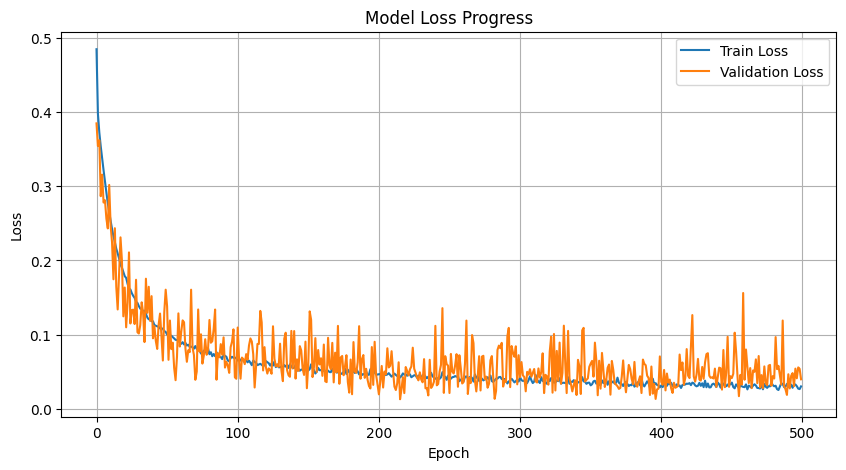

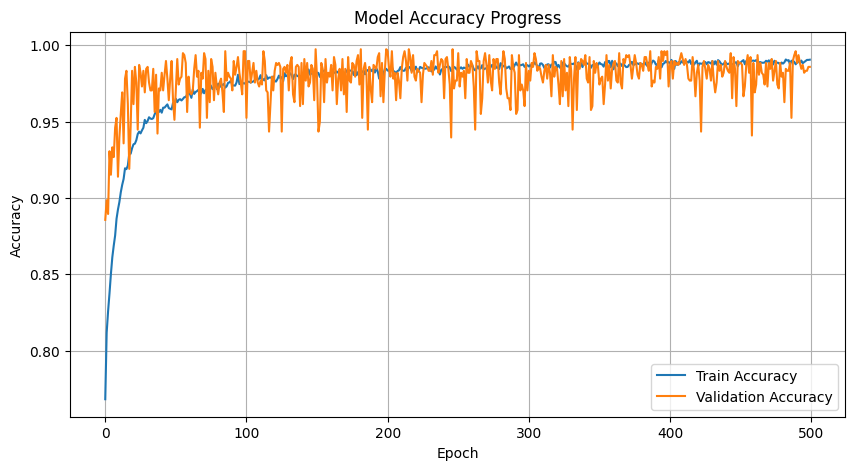

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Progress')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# **Logistic Regresssion Part**

In [ ]:
lr_define = LogisticRegression(random_state=42, max_iter=1000)

print("Logistic Regression Training: ")
lr_define.fit(X_train_res, y_train_res)

y_predict_lr = lr_define.predict(X_test)

print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_predict_lr) * 100:.2f}%")

Logistic Regression Training: 
Logistic Regression Test Accuracy: 73.87%


# **Evaluation Part**

In [ ]:
models = {
    "Logistic Regression": lr_define,
    "KNN": knn_define,
    "Neural Network": model_define
}

# **Compute ROC & AUC and Plot**

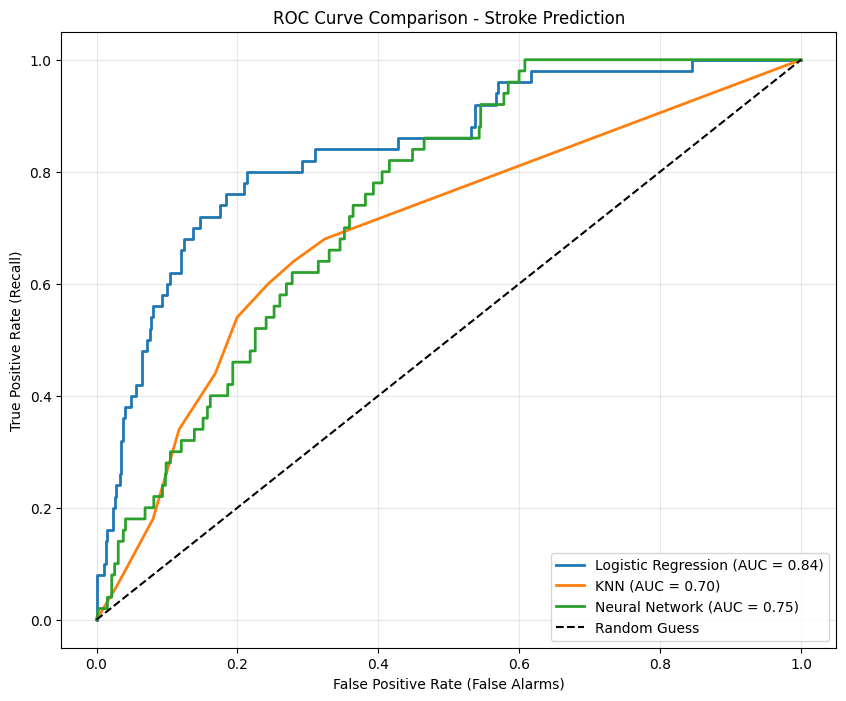

In [ ]:
plt.figure(figsize=(10, 8))

for name, model in models.items():

    if name == "Neural Network":
        y_probs = model.predict(X_test, verbose=0).ravel()
    else:
        y_probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel("False Positive Rate (False Alarms)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison - Stroke Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# **Multiclass Confusion Matrix & Accuracy**

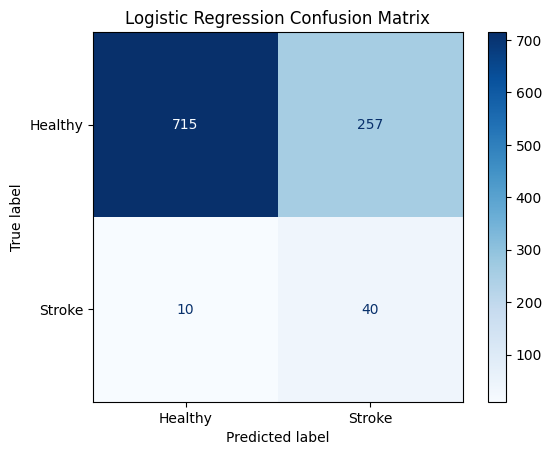

 Logistic Regression Accuracy: 73.87%
------------------------------


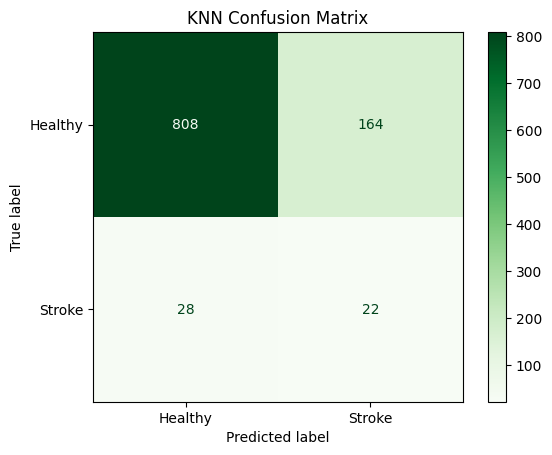

 KNN Accuracy: 81.21%
------------------------------


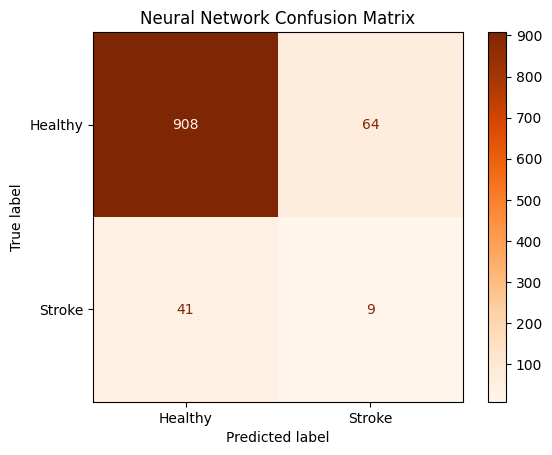

 Neural Network Accuracy: 89.73%
------------------------------


In [ ]:
colors = {"Logistic Regression": "Blues", "KNN": "Greens", "Neural Network": "Oranges"}

for name, model in models.items():

    if name == "Neural Network":
        y_pred = (model.predict(X_test, verbose=0) > 0.5).astype("int32")
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Stroke'])

    disp.plot(cmap=colors.get(name, "Blues"))
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    acc = accuracy_score(y_test, y_pred)
    print(f" {name} Accuracy: {acc:.2%}")
    print("-" * 30)

# **Classification Report: Precision, Accuracy, Recall, f1-Score**

--- Logistic Regression ---
              precision    recall  f1-score   support

     Healthy       0.99      0.74      0.84       972
      Stroke       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022



--- KNN ---
              precision    recall  f1-score   support

     Healthy       0.97      0.83      0.89       972
      Stroke       0.12      0.44      0.19        50

    accuracy                           0.81      1022
   macro avg       0.54      0.64      0.54      1022
weighted avg       0.93      0.81      0.86      1022



--- Neural Network ---
              precision    recall  f1-score   support

     Healthy       0.96      0.93      0.95       972
      Stroke       0.12      0.18      0.15        50

    accuracy                           0.90      1022
   macro avg       0.54      0.56      0.55      1022
weighte

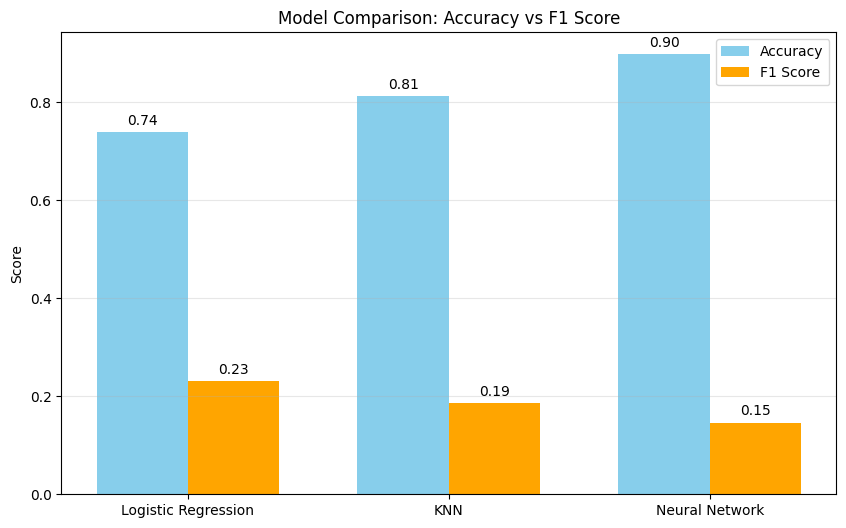

In [ ]:
model_names = []
accuracies = []
f1_scores = []

for name, model in models.items():
    print(f"--- {name} ---")

    model_names.append(name)

    if name == "Neural Network":
        y_pred = (model.predict(X_test, verbose=0) > 0.5).astype("int32")
    else:
        y_pred = model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    print(classification_report(y_test, y_pred, target_names=['Healthy', 'Stroke']))
    print("\n" + "="*50 + "\n")


x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='orange')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
ax.grid(axis='y', alpha=0.3)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()

# **Unsupervised Learning and K-Means Clustering Part**


In [ ]:
k_range = range(1, 11)
SSE = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    SSE.append(km.inertia_)
SSE

[76635.00000000007,
 64864.00227672798,
 58693.359882939345,
 53302.06229692644,
 48475.147234300115,
 45211.843637363556,
 43213.87836542206,
 38487.93116032482,
 34497.41249859041,
 34026.91317675333]

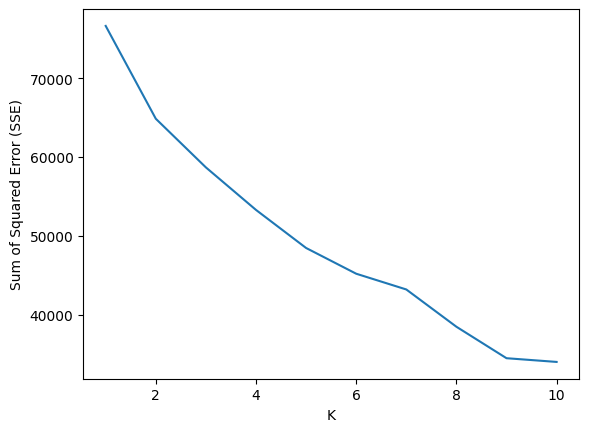

In [ ]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error (SSE)")
plt.plot(k_range, SSE)
plt.show()

# **K-Means Clustering**

In [ ]:
def implement_KMC(data, cluster_num):
    km_define = KMeans(n_clusters=cluster_num)
    y_predicted = km_define.fit_predict(data)
    return km_define, y_predicted

cluster = 2
km, y_predicted = implement_KMC(X_scaled, cluster)

print("Cluster centers shape:", km.cluster_centers_.shape)

Cluster centers shape: (2, 15)


# **K-Means Clustering Visualization**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


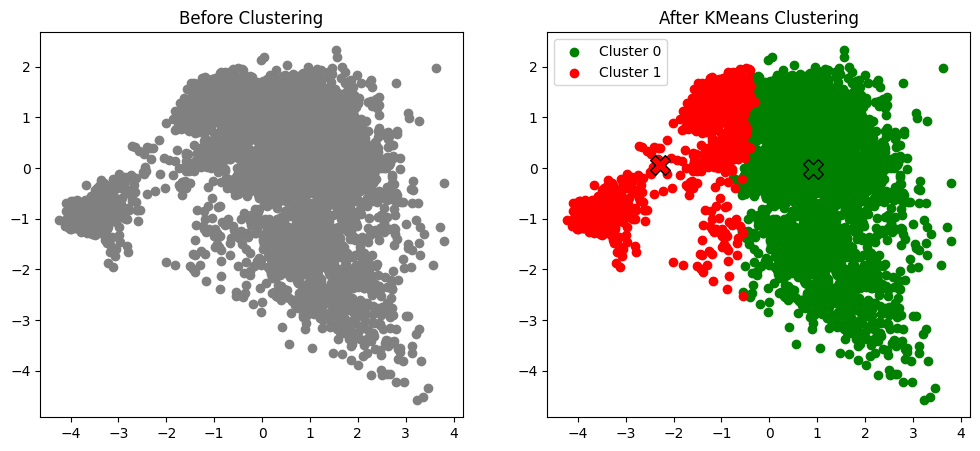

In [ ]:
pca_define = PCA(n_components=2)
X_pca_define = pca_define.fit_transform(X_scaled)

df_plotSet = pd.DataFrame(X_pca_define, columns=['PCA1', 'PCA2'])
df_plotSet['Group_cluster'] = y_predicted

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(df_plotSet['PCA1'], df_plotSet['PCA2'], color='gray')
axs[0].set_title("Before Clustering")

colors_lst = ['green', 'red']

for i in range(cluster):
    subset = df_plotSet[df_plotSet.Group_cluster == i]
    axs[1].scatter(subset['PCA1'], subset['PCA2'], color=colors_lst[i], label=f'Cluster {i}')

    centroid_2d = pca_define.transform(km.cluster_centers_)
    axs[1].scatter(centroid_2d[i, 0], centroid_2d[i, 1],
                   color=colors_lst[i], s=200, marker='X', edgecolors='black')

axs[1].set_title("After KMeans Clustering")
axs[1].legend()
plt.show()

# **Cluster Label vs Actual Stroke Prediction**

In [ ]:
print("\n--- Cluster Quality Check ---")
print(pd.crosstab(y_predicted, y, rownames=['Cluster'], colnames=['Actual Stroke']))


--- Cluster Quality Check ---
Actual Stroke     0    1
Cluster                 
0              3401  246
1              1459    3


# **Cluster Centers and Predictions**

In [ ]:
print("Cluster Centers:")
print(km.cluster_centers_)

predictions = km.labels_
print("\nPrediction for the KMeans Cluster")
print(predictions)

Cluster Centers:
[[ 0.48548962  0.12989444  0.09458535  0.10927295  0.27772785 -0.02714904
   0.55394434 -0.06576283  0.10903632  0.14750366 -0.39415678  0.00761039
   0.13117765  0.06894404  0.08178323]
 [-1.21106747 -0.32402531 -0.23594582 -0.27258445 -0.69279991  0.06772405
  -1.38182969  0.16404722 -0.27199417 -0.36795201  0.98323514 -0.01898432
  -0.32722633 -0.17198284 -0.20401055]]

Prediction for the KMeans Cluster
[0 0 0 ... 0 0 0]


# **Evaluation Part**

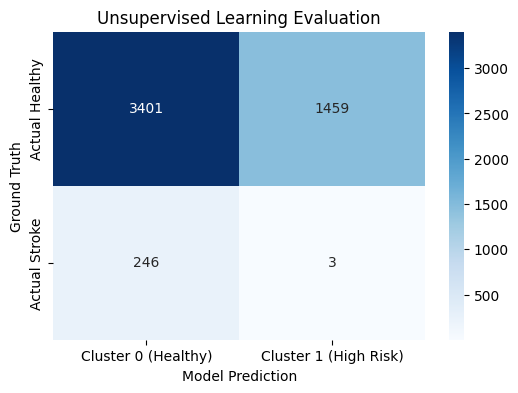

In [ ]:
labels = [0, 1]

cm = confusion_matrix(y, predictions, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cluster 0 (Healthy)', 'Cluster 1 (High Risk)'],
            yticklabels=['Actual Healthy', 'Actual Stroke'])
plt.title('Unsupervised Learning Evaluation')
plt.ylabel('Ground Truth')
plt.xlabel('Model Prediction')
plt.show()